# RAKSHAK — Exploratory Data Analysis (UNSW-NB15)

Working notebook for `data/processed/unsw_clean.parquet`, produced by `src/preprocess.py`'s `load_unsw_nb15()`: labels mapped from UNSW's original `attack_cat` values onto the same 5 unified classes CICIDS2017 uses (via `UNSW_LABEL_MAP`), `proto`/`service`/`state` label-encoded, inf/NaN rows and constant columns dropped. **Not yet scaled**, same reasoning as `01_eda.ipynb` — scaling only happens after a train/test split, so these are still original, interpretable units.

**Worth understanding before reading further**: UNSW-NB15 was captured with a completely different tool (Argus, not CICFlowMeter), so its columns share almost no names with CICIDS2017's — `dur` instead of `Flow Duration`, `sbytes`/`dbytes` instead of `Total Length of Fwd/Bwd Packets`, and a family of `ct_*` columns (rolling counts of similar recent connections) that CICIDS2017 has no equivalent for at all. This is exactly why `preprocess.py` builds a separate, smaller *common* feature schema (`unsw_common.parquet`/`cicids_common.parquet`) for actual cross-dataset validation in Phase 5 — a model trained on CICIDS2017's 25 selected features literally cannot run on this dataframe.

Also worth a critical eye: `UNSW_LABEL_MAP` is a judgment call, not a fact. UNSW-NB15's original 9 attack categories don't line up one-to-one with CICIDS2017's DoS/Probe/R2L/U2R taxonomy, so some mapping decisions are debatable — e.g. `Generic` (a class of attacks against block-cipher weaknesses) gets folded into `DoS`, and `Shellcode`/`Worms` become `U2R`. Keep this in mind when interpreting cross-dataset results later: some of any performance gap could come from taxonomy mismatch, not just genuine distribution shift.

Goals for this notebook (same structure as `01_eda.ipynb`, for direct comparison):
1. Sanity-check the loaded data
2. Class distribution — and how it compares to CICIDS2017's
3. Correlation heatmap of the top features
4. Box plots of the top 5 features by class
5. Class imbalance observations — and why this dataset's imbalance profile matters for Phase 5

## 1. Load and sanity-check the data

Same pattern as `01_eda.ipynb`: confirm the parquet round-tripped correctly, and get a first look at how different this schema actually is from CICIDS2017's.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

UNSW_PATH = PROJECT_ROOT / "data" / "processed" / "unsw_clean.parquet"

df = pd.read_parquet(UNSW_PATH)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (153684, 43)

Dtypes:
dur                  float64
proto                  int64
service                int64
state                  int64
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,Label
0,0.000011,119,0,5,2,0,496,0,90909.0902,254,...,1,1,2,0,0,0,1,2,0,Normal
1,0.000008,119,0,5,2,0,1762,0,125000.0003,254,...,1,1,2,0,0,0,1,2,0,Normal
2,0.000005,119,0,5,2,0,1068,0,200000.0051,254,...,1,1,3,0,0,0,1,3,0,Normal
3,0.000006,119,0,5,2,0,900,0,166666.6608,254,...,2,1,3,0,0,0,2,3,0,Normal
4,0.000010,119,0,5,2,0,2126,0,100000.0025,254,...,2,1,3,0,0,0,2,3,0,Normal


**Observations:** *(rewrite in your own words)*

- 153,684 rows × 43 columns — versus CICIDS2017's 2,827,876 rows × 71 columns. UNSW-NB15 is roughly **18x smaller** and has **28 fewer feature columns**.
- Every feature column is already numeric — `proto`/`service`/`state` were label-encoded by `preprocess.py` before this parquet was saved (unlike CICIDS2017, which had no categorical columns to begin with).
- Column names are unrecognizable next to CICIDS2017's: no `Flow Duration`, no `Fwd`/`Bwd` naming convention at all. Confirms the common-schema approach in `preprocess.py` is necessary, not just a convenience.

## 2. Class distribution

Same plot as `01_eda.ipynb` Section 2 — but this time worth comparing the actual proportions side by side with CICIDS2017, not just looking at this dataset in isolation.

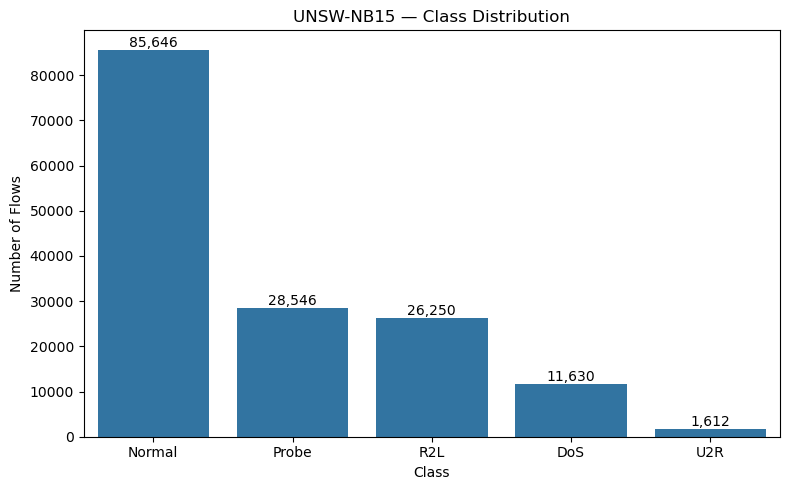

Label
Normal    85646
Probe     28546
R2L       26250
DoS       11630
U2R        1612
Name: count, dtype: int64

In [2]:
label_counts = df["Label"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title("UNSW-NB15 — Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Flows")
for i, count in enumerate(label_counts.values):
    ax.text(i, count, f"{count:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

label_counts

In [3]:
# Side-by-side comparison with CICIDS2017's proportions (hardcoded from
# 01_eda.ipynb's Section 2 output - both are static, already-processed files,
# so this doesn't need to be recomputed here).
comparison = pd.DataFrame(
    {
        "CICIDS2017 (%)": {"Normal": 80.32, "DoS": 13.43, "Probe": 5.62, "R2L": 0.57, "U2R": 0.07},
        "UNSW-NB15 (%)": (df["Label"].value_counts(normalize=True) * 100).round(2),
    }
)
comparison

,CICIDS2017 (%),UNSW-NB15 (%)
DoS,13.43,7.57
Normal,80.32,55.73
Probe,5.62,18.57
R2L,0.57,17.08
U2R,0.07,1.05


**Observations:** *(rewrite in your own words)*

- Normal: 85,646 (55.7%) · Probe: 28,546 (18.6%) · R2L: 26,250 (17.1%) · DoS: 11,630 (7.6%) · U2R: 1,612 (1.0%).
- This is a dramatically different imbalance profile than CICIDS2017. In CICIDS2017, Normal dominates at 80% and U2R is a vanishing 0.07% — a ~1,140:1 ratio. Here, Normal is only 56%, and **U2R is proportionally ~15x more common** (1.05% vs 0.07%), while **R2L is proportionally ~30x more common** (17.1% vs 0.57%).
- Practical implication for Phase 5: a model trained on CICIDS2017 has learned decision boundaries calibrated to U2R/R2L being extremely rare exceptions. Evaluated zero-shot on UNSW-NB15 — where those same classes are common — its precision/recall balance for those classes will very likely look different, in either direction, purely from this distribution shift, independent of whether the underlying attack *patterns* generalize at all.

## 3. Correlation heatmap (top features)

Same method as `01_eda.ipynb` Section 3: rank features by absolute correlation with a numeric-encoded `Label`, then plot the heatmap. UNSW-NB15 only has 42 numeric features total (versus CICIDS2017's 70), so "top 30" here covers most of the dataset rather than a small slice of it — worth keeping in mind when comparing how concentrated or spread out the correlated features look.

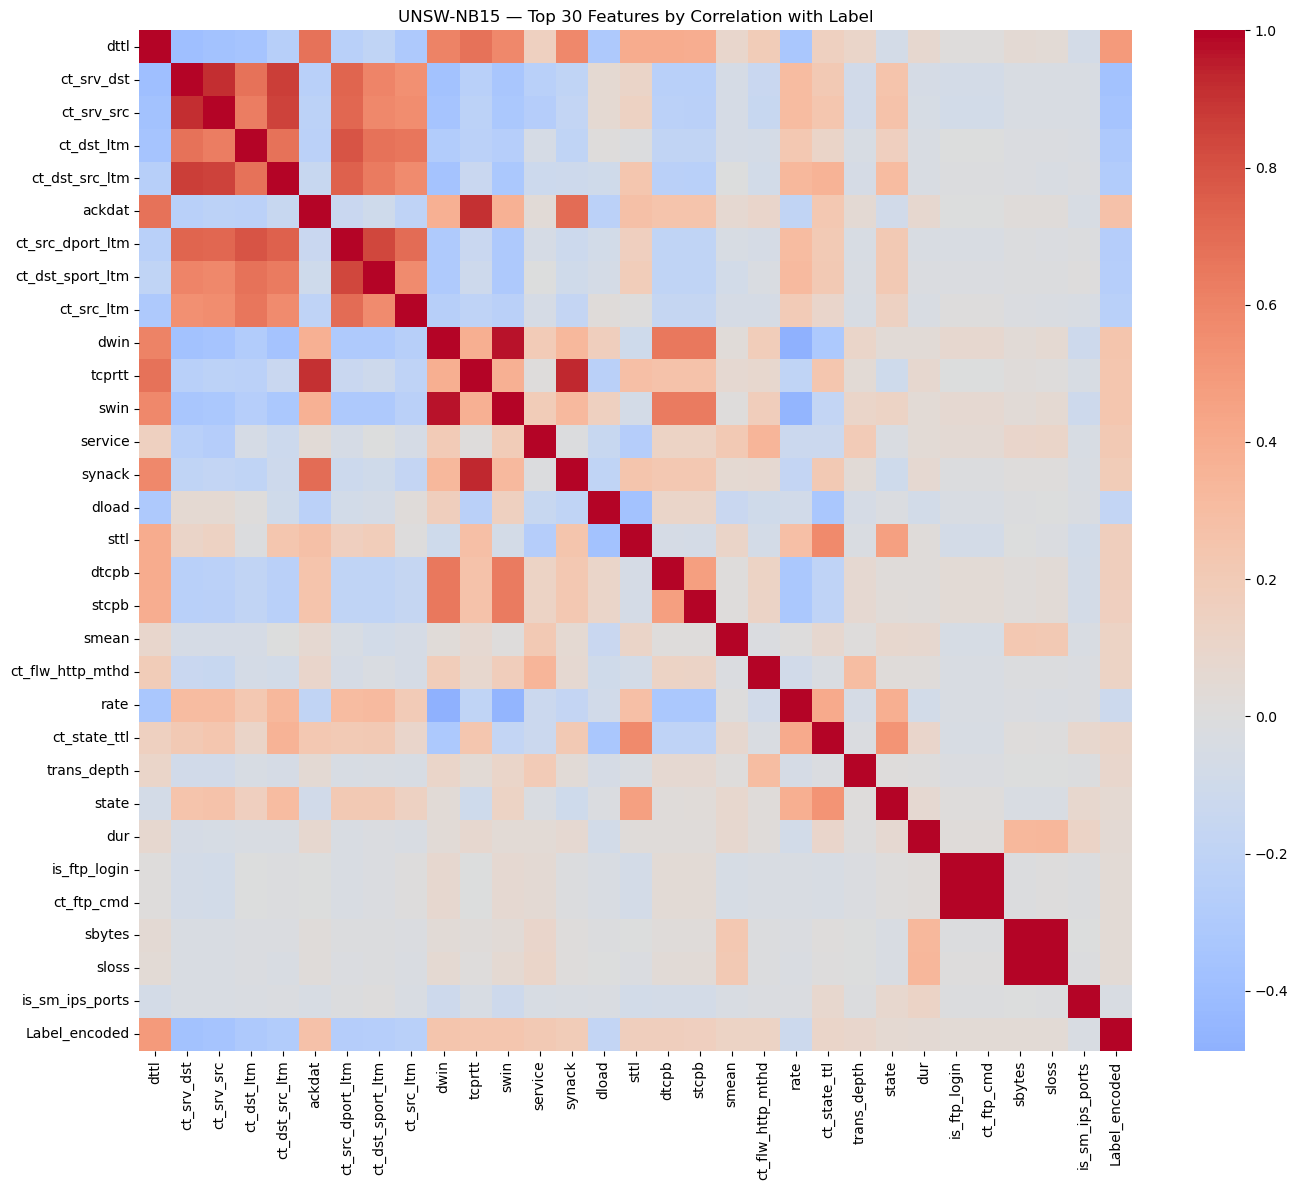

In [4]:
from sklearn.preprocessing import LabelEncoder

# Throwaway encoder for this plot only - not saved, same as 01_eda.ipynb.
label_encoded = LabelEncoder().fit_transform(df["Label"])

numeric_df = df.drop(columns=["Label"]).select_dtypes(include="number").copy()
numeric_df["Label_encoded"] = label_encoded

correlations = numeric_df.corr()["Label_encoded"].drop("Label_encoded")
top_30_features = correlations.abs().sort_values(ascending=False).head(30).index.tolist()

corr_matrix = numeric_df[top_30_features + ["Label_encoded"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("UNSW-NB15 — Top 30 Features by Correlation with Label")
plt.tight_layout()
plt.show()

**Observations:** *(rewrite in your own words)*

- Top correlated features: `dttl` (0.4955), `ct_srv_dst` (-0.3698), `ct_srv_src` (-0.3530), `ct_dst_ltm` (-0.3058), `ct_dst_src_ltm` (-0.2850), `ackdat` (0.2691), `ct_src_dport_ltm` (-0.2688), `ct_dst_sport_ltm` (-0.2650), `ct_src_ltm` (-0.2484), `dwin` (0.2472).
- Very different signal family than CICIDS2017. There, packet-size and timing stats dominated. Here, `dttl` (destination time-to-live) and a whole cluster of `ct_*` features — rolling counts of connections sharing the same service/destination/source over a recent time window — dominate instead. This makes sense given Argus computes connection-level aggregate statistics that CICFlowMeter doesn't track at all.
- Caveat, same as `01_eda.ipynb`: this is linear correlation against an arbitrarily-ordered label encoding — a first-pass signal, not ground truth. Real feature importance would come from a trained model, same as Phase 3 did for CICIDS2017.

## 4. Box plots — top 5 features by class

Reusing the correlation ranking from Section 3, same as `01_eda.ipynb` Section 4.

Top 5 features by |correlation| with Label: ['dttl', 'ct_srv_dst', 'ct_srv_src', 'ct_dst_ltm', 'ct_dst_src_ltm']


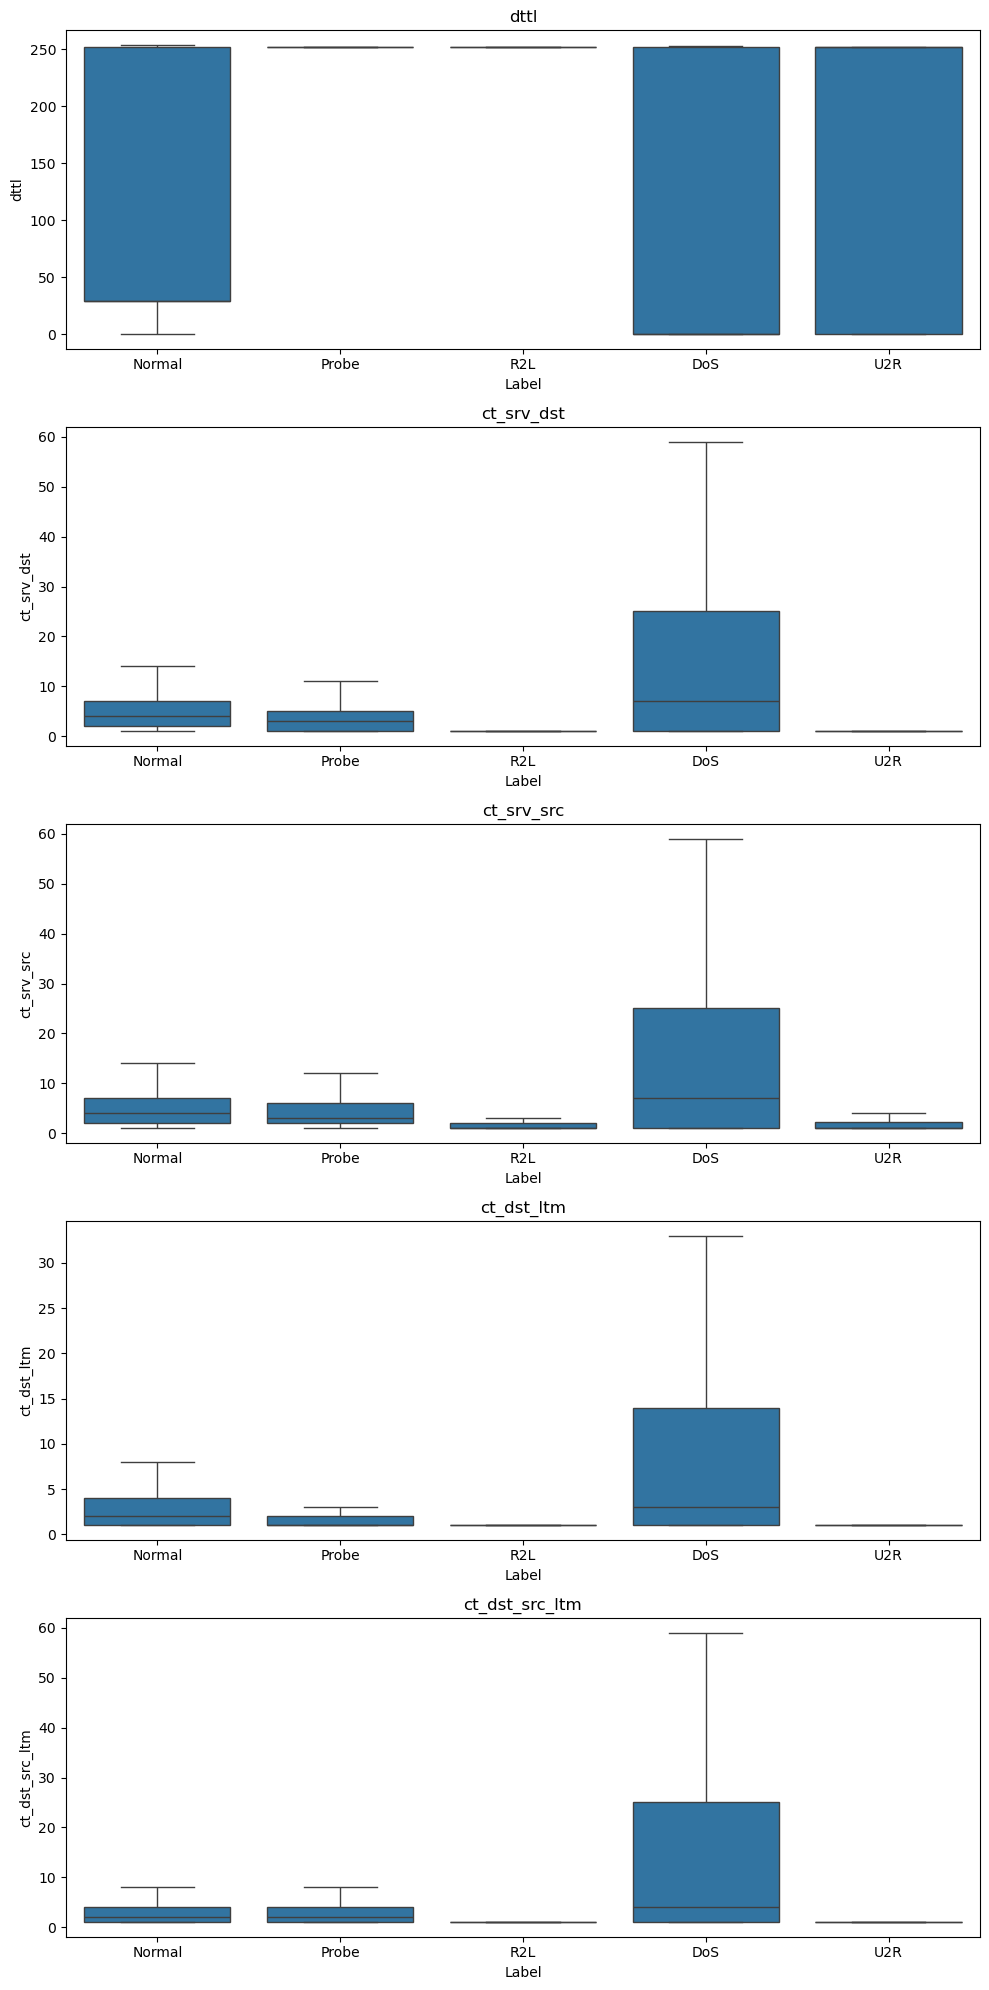

In [5]:
top_5_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()
print("Top 5 features by |correlation| with Label:", top_5_features)

fig, axes = plt.subplots(nrows=len(top_5_features), ncols=1, figsize=(10, 4 * len(top_5_features)))
for ax, feature in zip(axes, top_5_features):
    sns.boxplot(data=df, x="Label", y=feature, ax=ax, showfliers=False)
    ax.set_title(feature)
plt.tight_layout()
plt.show()

**Observations:** *(rewrite in your own words — look at the actual plot to confirm or refute this)*

- All 5 top features are either TTL-based (`dttl`) or `ct_*` rolling-connection-count features — a completely different feature family than CICIDS2017's packet-size-dominated top 5. Hypothesis to check against the plot: `ct_*` features count how many similar recent connections there were, so scanning/reconnaissance-style traffic (many connections to the same service in a short window) should show elevated `ct_srv_dst`/`ct_srv_src` compared to Normal's more varied one-off connections. Confirm whether Probe's box actually sits higher than Normal's in the rendered plot.

## 5. Class imbalance summary

*(rewrite in your own words)*

U2R (1,612 rows, 1.05% of the dataset) is still the smallest class here, but nowhere near as extreme as CICIDS2017's 0.07% — proportionally about 15x more represented. R2L (26,250 rows, 17.1%) isn't a minority class at all in this dataset, unlike CICIDS2017 where it's 0.57%.

This matters directly for Phase 5's cross-dataset validation: it means UNSW-NB15 isn't just "a second test set" — it's testing generalization under a genuinely different label distribution, not just different underlying traffic. A meaningful drop in cross-dataset performance could be explained by real generalization failure, by this distribution shift, or by the `UNSW_LABEL_MAP` taxonomy mismatch noted in Section 1 — worth trying to disentangle these three explanations rather than collapsing them into a single "the model doesn't generalize" conclusion when writing up Phase 5's results.